# Nelder-Mead trajectory analysis

Parameter, iteration-count, and trace-distance trajectories from a Nelder-Mead `summary_0.json`.

In [27]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RUN = '2'
POINT = '001'
SUMMARY_PATH = Path('data/nelder_mead/nelder_mead_N4_h_sweep_'+RUN+'_runs/point_'+POINT+'/summary_0.json')
PARAMETERS = ['alpha', 'omega_max', 'sigma', 'T', 'tau']
PARAMETER_LABELS = {
    'alpha': r'$\alpha$',
    'omega_max': r'$\omega_{\max}$',
    'sigma': r'$\sigma$',
    'T': r'$T$',
    'tau': r'$\tau$',
}


In [28]:
with SUMMARY_PATH.open() as file:
    summary = json.load(file)

trajectory = pd.json_normalize(summary['history'])
trajectory = trajectory.rename(columns={f'parameters.{name}': name for name in PARAMETERS})
trajectory['valid'] = trajectory['status'].eq('valid')
trace_distance_tol = summary['fixed_parameters']['trace_distance_tol']

print(f"Loaded {len(trajectory)} evaluations from {SUMMARY_PATH}")
print(f"Optimizer status: {summary['message']}")

trajectory.head()

Loaded 78 evaluations from data/nelder_mead/nelder_mead_N4_h_sweep_2_runs/point_001/summary_0.json
Optimizer status: Stopped after 5 consecutive equal valid iteration counts.


,evaluation,num_iterations,trace_distance,status,objective,alpha,omega_max,sigma,T,tau,valid
0,1,283.0,0.022476,valid,283.0,0.7500,8.0,2.0,25.00,0.1,True
1,2,358.0,0.018851,valid,358.0,0.7875,8.0,2.0,25.00,0.1,True
2,3,365.0,0.020936,valid,365.0,0.7500,8.4,2.0,25.00,0.1,True
3,4,349.0,0.023492,valid,349.0,0.7500,8.0,2.1,25.00,0.1,True
4,5,288.0,0.022954,valid,288.0,0.7500,8.0,2.0,26.25,0.1,True


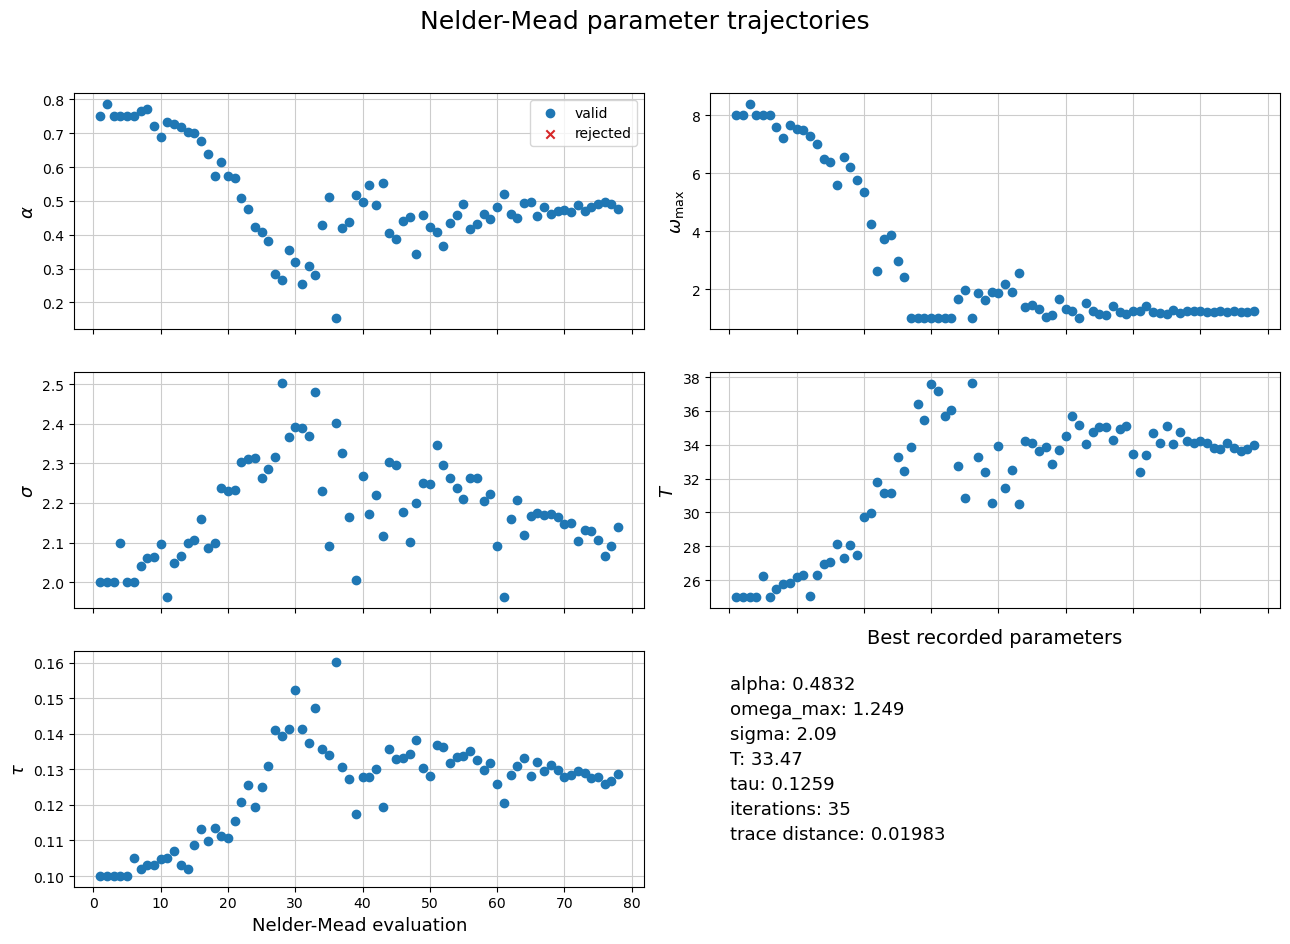

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
axes = axes.ravel()

for ax, parameter in zip(axes, PARAMETERS):
    ax.scatter(
        trajectory.loc[trajectory['valid'], 'evaluation'],
        trajectory.loc[trajectory['valid'], parameter],
        color='tab:blue', label='valid', zorder=3,
    )
    ax.scatter(
        trajectory.loc[~trajectory['valid'], 'evaluation'],
        trajectory.loc[~trajectory['valid'], parameter],
        color='tab:red', marker='x', label='rejected', zorder=3,
    )
    ax.set_ylabel(PARAMETER_LABELS[parameter], fontsize=13)
    ax.set_axisbelow(True)
    ax.grid(True, color='0.8', linewidth=0.8)

best = summary['best_valid_evaluation']
best_parameters = best['parameters']
summary_lines = [
    f"{parameter}: {best_parameters[parameter]:.4g}"
    for parameter in PARAMETERS
]
summary_lines.extend([
    f"iterations: {best['num_iterations']:.0f}",
    f"trace distance: {best['trace_distance']:.4g}",
])
axes[-1].axis('off')
axes[-1].set_title('Best recorded parameters', fontsize=14)
axes[-1].text(0.05, 0.9, '\n'.join(summary_lines), va='top', fontsize=13, linespacing=1.5)
for ax in axes[-2:]:
    if ax.axison:
        ax.set_xlabel('Nelder-Mead evaluation', fontsize=13)
axes[0].legend()
fig.suptitle('Nelder-Mead parameter trajectories', fontsize=18)
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()

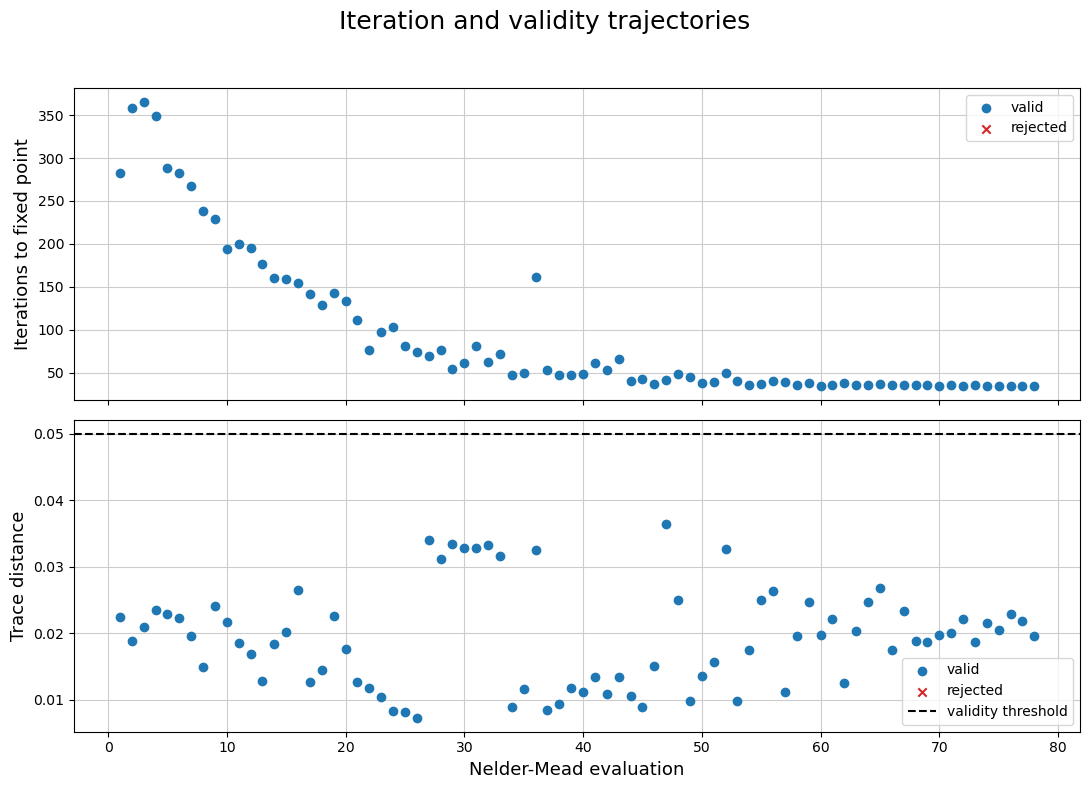

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].scatter(
    trajectory.loc[trajectory['valid'], 'evaluation'],
    trajectory.loc[trajectory['valid'], 'num_iterations'],
    color='tab:blue', label='valid', zorder=3,
)
axes[0].scatter(
    trajectory.loc[~trajectory['valid'], 'evaluation'],
    trajectory.loc[~trajectory['valid'], 'num_iterations'],
    color='tab:red', marker='x', label='rejected', zorder=3,
)
axes[0].set_ylabel('Iterations to fixed point', fontsize=13)
axes[0].legend()

axes[1].scatter(
    trajectory.loc[trajectory['valid'], 'evaluation'],
    trajectory.loc[trajectory['valid'], 'trace_distance'],
    color='tab:blue', label='valid', zorder=3,
)
axes[1].scatter(
    trajectory.loc[~trajectory['valid'], 'evaluation'],
    trajectory.loc[~trajectory['valid'], 'trace_distance'],
    color='tab:red', marker='x', label='rejected', zorder=3,
)
axes[1].axhline(trace_distance_tol, color='black', linestyle='--', label='validity threshold')
axes[1].set_xlabel('Nelder-Mead evaluation', fontsize=13)
axes[1].set_ylabel('Trace distance', fontsize=13)
axes[1].legend()

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(True, color='0.8', linewidth=0.8)
fig.suptitle('Iteration and validity trajectories', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## This section is for extracting the optimal values from a N-M sweep run

Convert a Nelder-Mead h/J sweep into a grid-analysis archive. Set the sweep number and output grid number, run the cell, then load that number in `grid_analysis.ipynb`.


In [32]:
nelder_mead_sweep_number = 2
N = 4
run_dir = Path(f'data/nelder_mead/nelder_mead_N{N}_h_sweep_{nelder_mead_sweep_number}_runs')
output_path = run_dir / f'nelder_mead_N{N}_h_sweep_{nelder_mead_sweep_number}_grid_analysis.npz'
archive_keys = ['h', 'eigvals', 'Delta_sep', 'Delta_gap', 'Delta_th', 'num_closer', 'normality_residual']

rows = []
for point_dir in sorted(run_dir.glob('point_*')):
    summary_path = point_dir / 'summary_0.json'
    if not summary_path.exists():
        print(f"Skipping {point_dir.name}: no summary_0.json")
        continue
    summary = json.loads(summary_path.read_text())
    best = summary['best_valid_evaluation']
    if best is None:
        print(f"Skipping {point_dir.name}: no valid optimum")
        continue
    params = best['parameters']
    archive = np.load(point_dir / f'superoperator_N{N}_single_0.npz')

    row = {key: archive[key].item() if archive[key].shape == () else archive[key] for key in archive_keys}
    row.update(summary['fixed_parameters'])
    row.update({key: params[key] for key in ['alpha', 'sigma', 'omega_max', 'T', 'tau']})
    row.update(num_iterations=best['num_iterations'], trace_distance=best['trace_distance'])
    rows.append(row)
    archive.close()

nelder_mead_grid_data = pd.DataFrame(rows).sort_values('h_over_J')
output_path.parent.mkdir(parents=True, exist_ok=True)

payload = {
    key: nelder_mead_grid_data[key].to_numpy(float)
    for key in [
        'h', 'alpha', 'sigma', 'omega_max', 'beta', 'h_over_J',
        'Delta_sep', 'Delta_th', 'trace_distance', 'num_iterations',
        'Delta_gap', 'normality_residual', 'T', 'tau',
    ]
}
payload.update(
    eigvals=np.stack(nelder_mead_grid_data['eigvals']),
    num_closer=nelder_mead_grid_data['num_closer'].to_numpy(int),
    channels=np.empty(0),
)
np.savez_compressed(output_path, **payload)

print(f'Saved {len(nelder_mead_grid_data)} optimized points to {output_path}')
nelder_mead_grid_data


Saved 10 optimized points to data/nelder_mead/nelder_mead_N4_h_sweep_2_runs/nelder_mead_N4_h_sweep_2_grid_analysis.npz


,h,eigvals,Delta_sep,Delta_gap,Delta_th,num_closer,normality_residual,N,J,h_over_J,...,workers,trace_distance_tol,dense_spectrum,alpha,sigma,omega_max,T,tau,num_iterations,trace_distance
0,0.049029,"[(-0.49029231046562327-0.48641056548005834j), ...",0.060699,0.060699,0.0,0,NaN,4,1.0,0.2,...,8,0.05,True,0.483244,2.090126,1.249444,33.474573,0.125875,35.0,0.019830
1,0.092848,"[(0.9999999999999897-1.5543122344752192e-15j),...",0.099606,0.099606,0.0,0,NaN,4,1.0,0.4,...,8,0.05,True,0.492909,1.985619,1.274433,34.144065,0.128393,20.0,0.027599
2,0.128624,"[(1.0000000000000655+4.440892098500626e-16j), ...",0.123160,0.123160,0.0,0,NaN,4,1.0,0.6,...,8,0.05,True,0.492909,1.985619,1.274433,34.144065,0.128393,16.0,0.031687
3,0.156174,"[(0.9999999999999847+3.3306690738754696e-16j),...",0.131578,0.131578,0.0,0,NaN,4,1.0,0.8,...,8,0.05,True,0.517555,1.985619,1.274433,34.144065,0.128393,13.0,0.036765
4,0.176777,"[(0.9999999999999822+1.2212453270876722e-15j),...",0.141410,0.141410,0.0,0,NaN,4,1.0,1.0,...,8,0.05,True,0.540638,1.976883,1.254806,34.813289,0.126595,10.0,0.040483
5,0.192055,"[(0.9999999999999941+3.0531133177191805e-16j),...",0.144680,0.144680,0.0,0,NaN,4,1.0,1.2,...,8,0.05,True,0.567670,1.976883,1.254806,34.813289,0.126595,10.0,0.042719
6,0.203433,"[(0.9999999999999634+1.1102230246251565e-16j),...",0.142944,0.142944,0.0,0,NaN,4,1.0,1.4,...,8,0.05,True,0.596053,1.976883,1.254806,34.813289,0.126595,9.0,0.045010
7,0.212000,"[(0.9999999999999754-4.440900568830099e-16j), ...",0.139022,0.139022,0.0,0,NaN,4,1.0,1.6,...,8,0.05,True,0.596053,1.976883,1.254806,34.813289,0.126595,9.0,0.043198
8,0.218539,"[(-0.6376522834979339+0.15185724475575157j), (...",0.132175,0.132175,0.0,0,NaN,4,1.0,1.8,...,8,0.05,True,0.596053,1.976883,1.254806,36.553953,0.126595,8.0,0.041665
9,0.223607,"[(1.00000000000005+1.2212453270876722e-15j), (...",0.120213,0.120213,0.0,0,NaN,4,1.0,2.0,...,8,0.05,True,0.596053,1.976883,1.254806,36.553953,0.126595,7.0,0.039629
